In [1]:
import pandas as pd
import numpy as np
import re

import pymc as pm
import arviz as az
import nutpie
import matplotlib.pyplot as plt

import bambi as bmb 
def calc_rate(guesses:list[int]):
    ids = [idx+1 for idx, i in enumerate(guesses)]
    cs = np.cumsum(guesses)
    return cs/ids

def find_win(l:list):
    """ if last 10 were correct"""
    if np.mean(l[-10:]) == 1:
        return "Win"
    else: 
        return "Lose"

def count_turns(l:list):
    "how many responses were given in a game"
    return len(l)

def count_wins(l:list):
    "count correct responses"
    return len([i for i in l if i == 1])

def total_time(l:list):
    "last wall_time - first wall_time"
    return float(l[-1]) - float(l[0])

WARNING (pytensor.configdefaults): g++ not available, if using conda: `conda install gxx`
WARNING (pytensor.configdefaults): g++ not detected!  PyTensor will be unable to compile C-implementations and will default to Python. Performance may be severely degraded. To remove this warning, set PyTensor flags cxx to an empty string.


In [2]:
#plot human rates
#human data
a_df = pd.read_csv("../data/AlienData.csv", dtype="object")
rule_ids = pd.read_csv("../data/rule_ids.csv", dtype = "object")
#turn cols to float
a_df["points"] = [float(i) for i  in a_df["points"]]
a_df["correct"] = [float(i) for i  in a_df["correct"]]
# keep only the test
a_df = a_df[a_df["block"] == "test"]
#47+(90/2)+(88/2) = 136
#There should be 136 total games in the test phase
#differentiate IDS
a_df["trial_id"] = a_df["rule_num"] + "_" + a_df["trial"]
a_df["game_id"] = a_df["unique_id"] + "_" + a_df["rule_num"]
a_df["full_id"] = a_df["unique_id"] + "_" + a_df["trial_id"]
#select important columns
a_df_small = a_df[["unique_id","game_id","full_id","stimulus","choice","correct","rule_num","rule_id","wall_time"]]
#pivot the dataframe to have all games in 1 row
id_list = []
stim_list = []
choice_list= []
correct_list = []
rule_id_list = []
rule_num_list = []
wall_time_list = []

#separate by games
for u_id in sorted(list(set(a_df_small["game_id"]))):
    #select subset
    subs = a_df_small[a_df_small["game_id"] == u_id]
    #collect vals
    id_list.append(u_id)
    stim_list.append(list(subs["stimulus"]))
    choice_list.append(list(subs["choice"]))
    correct_list.append(list(subs["correct"]))
    rule_id_list.append(list(subs["rule_id"]))
    rule_num_list.append(list(subs["rule_num"]))
    wall_time_list.append(list(subs["wall_time"]))

#new frame
n_df = pd.DataFrame({"game_id":id_list,
                     "stims":stim_list,
                     "choices":choice_list,
                     "correct":correct_list,
                     "rule_id":rule_id_list,
                     "rule_num":rule_num_list,
                     "wall_time":wall_time_list})

#derive important values
n_df["win"] = n_df["correct"].map(find_win)
n_df["n_turns"] = n_df["correct"].map(count_turns)
n_df["n_correct"] = n_df["correct"].map(count_wins)
n_df["tt"] = n_df["wall_time"].map(total_time)
#add session ids
n_df = a_df[["game_id","unique_id","condition"]].drop_duplicates().merge(n_df,on="game_id")


#filter out last games which did not finish because time ran out
ids = list(set(n_df["unique_id"]))
last_g_ids = []
for i in ids:
    #separate sessions
    subs = n_df[n_df["unique_id"]==i]
    #separate games
    #max(last num after last _ in game_id)
    lc = np.max([int(re.findall(r"(\d+)[^_]*$",c)[0]) for c in list(subs["game_id"])])
    #lc = np.max([int(c[-1]) for c in list(subs["game_id"])])
    last_g_id = f"{i}_{lc}"
    last_g_ids.append(last_g_id)

#either not a last game, or a last game with win or a last game with tt over 400
full_df = n_df[(~n_df['game_id'].isin(last_g_ids)) | ((n_df['game_id'].isin(last_g_ids)) & (n_df["win"]=="Win")) | ((n_df['game_id'].isin(last_g_ids)) & (n_df["tt"]>=400))]

#nans (probably timeouts) to 0, technically they were "wrong answers"
def float_int_na_0(l:list):
    return [int(i) if i in [1,0] else 0 for i in l]
full_df["correct"] = full_df["correct"].map(float_int_na_0)

#check correct game evaluation
def rolling_c(cs:list,n_c:int=10)->int:
    """counts the occurrence of n_c 1s in a row in a list"""
    i_counter = 0
    meta_i_counter = 0
    for idx_i,i in enumerate(cs):
        if i == 1:
            i_counter += 1
        else:
            i_counter=0
        
        if i_counter == n_c:
            meta_i_counter +=1
            i_counter = 0
    return meta_i_counter

full_df["insp"] = full_df["correct"].map(rolling_c)
#full_df[full_df["insp"]==2]
# ONE game where it happened 2X
def calc_point_rate(l:list):
    pointrate = np.mean(l)
    if pointrate == 1:
        pointrate = 0.999

    return pointrate

full_df["point_rate"] = full_df["correct"].map(calc_point_rate)

In [3]:
full_df.head(1)

,game_id,unique_id,condition,stims,choices,correct,rule_id,rule_num,wall_time,win,n_turns,n_correct,tt,insp,point_rate
0,1_10_2_2,1_10_2,1_I,"[00110, 10110, 10101, 00000, 01110, 10100, 111...","[ignore, kill, ignore, ignore, kill, ignore, k...","[0, 1, 0, 1, 1, 0, 1, 0, 1, 0, 0, 1, 1, 0, 0, ...","[05, 05, 05, 05, 05, 05, 05, 05, 05, 05, 05, 0...","[2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, ...","[907.57380958, 911.136457293, 918.621201429, 9...",Lose,68,32,417.182558,0,0.470588


In [7]:
def select_one_val(l:list):
    return l[0]

full_df["one_r_id"] = full_df["rule_id"].map(select_one_val)
full_df["one_r_num"] = full_df["rule_num"].map(select_one_val)

ref_small = full_df.groupby(["one_r_id","one_r_num"]).agg(
    games = ("game_id","count")
).reset_index()

In [3]:
cut_df = full_df[["game_id","unique_id","condition","win","n_turns","n_correct",]]

In [ ]:
"""
                latency ~ 0 + Language:Task + (1|Pair) ,
                sigma ~ 0 + Language:Task + (1|Pair),
                #sigma ~ 1, # in the simulations sigma was not varied to keep it simple
                beta ~ 0 + Language:Task + (1|Pair)
                #beta ~  (1|Pair)# beta was also not dependent on condition
"""

In [16]:
model = bmb.Model("p(n_correct, n_turns) ~ 0 + win:condition + (1|unique_id)",cut_df, family="binomial")

In [6]:
import os
import graphviz
os.environ["PATH"] += os.pathsep + 'C:/Program Files/Graphviz/bin'

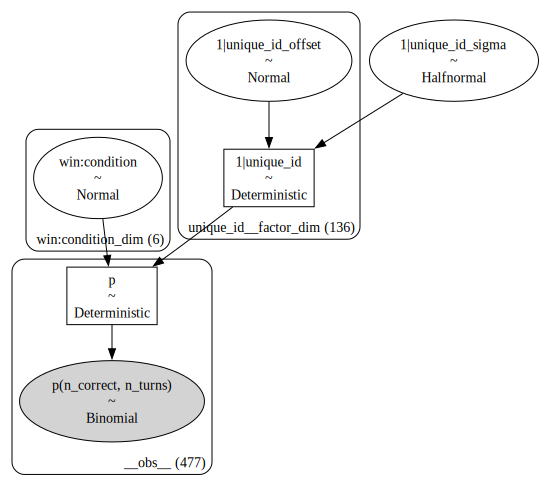

In [17]:
model.build()
model.graph()

In [8]:
print(model)

       Formula: p(n_correct, n_turns) ~ 0 + win:condition + (1|unique_id)
        Family: binomial
          Link: p = logit
  Observations: 477
        Priors: 
    target = p
        Common-level effects
            win:condition ~ Normal(mu: [0. 0. 0. 0. 0. 0.], sigma: [1. 1. 1. 1. 1. 1.])
        
        Group-level effects
            1|unique_id ~ Normal(mu: 0.0, sigma: HalfNormal(sigma: 2.5371))


In [12]:
# Fit the model using 1000 on each chain
nutpie_idata = model.fit(inference_method="nutpie", progressbar=True)

Progress,Draws,Divergences,Step Size,Gradients/Draw
,2000,0,0.42,7
,2000,0,0.48,15
,2000,0,0.45,15
,2000,0,0.42,15


In [47]:
# Key summary and diagnostic info on the model parameters
az.summary(nutpie_idata,var_names=["~p"])



,mean,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
"win:condition[Lose, 1_I]",0.307,0.037,0.240,0.375,0.001,0.001,2368.0,2484.0,1.0
"win:condition[Lose, 2_ND]",0.348,0.042,0.266,0.421,0.001,0.001,3234.0,2694.0,1.0
"win:condition[Lose, 3_D]",0.322,0.045,0.234,0.401,0.001,0.001,3225.0,2902.0,1.0
"win:condition[Win, 1_I]",0.791,0.036,0.720,0.856,0.001,0.001,2360.0,2293.0,1.0
"win:condition[Win, 2_ND]",0.833,0.054,0.738,0.940,0.001,0.001,3012.0,3013.0,1.0
...,...,...,...,...,...,...,...,...,...
1|unique_id[3_5_1],0.076,0.131,-0.177,0.308,0.002,0.002,4978.0,2428.0,1.0
1|unique_id[3_6_1],0.103,0.111,-0.110,0.302,0.002,0.002,4004.0,2964.0,1.0
1|unique_id[3_7_1],0.016,0.107,-0.188,0.215,0.002,0.002,4520.0,2822.0,1.0
1|unique_id[3_8_1],0.043,0.123,-0.189,0.267,0.002,0.002,4763.0,2805.0,1.0


In [48]:
nutpie_idata.posterior_predictive

<xarray.Dataset> Size: 15MB
Dimensions:                (chain: 4, draw: 1000, __obs__: 477)
Coordinates:
  * chain                  (chain) int64 32B 0 1 2 3
  * draw                   (draw) int64 8kB 0 1 2 3 4 5 ... 995 996 997 998 999
  * __obs__                (__obs__) int64 4kB 0 1 2 3 4 ... 472 473 474 475 476
Data variables:
    p(n_correct, n_turns)  (chain, draw, __obs__) int64 15MB 44 33 41 ... 22 9
Attributes:
    modeling_interface:          bambi
    modeling_interface_version:  0.17.2

array([[<Axes: title={'center': 'win:condition'}>,
        <Axes: title={'center': 'win:condition'}>],
       [<Axes: title={'center': '1|unique_id_sigma_log__'}>,
        <Axes: title={'center': '1|unique_id_sigma_log__'}>],
       [<Axes: title={'center': '1|unique_id_sigma'}>,
        <Axes: title={'center': '1|unique_id_sigma'}>],
       [<Axes: title={'center': '1|unique_id'}>,
        <Axes: title={'center': '1|unique_id'}>]], dtype=object)

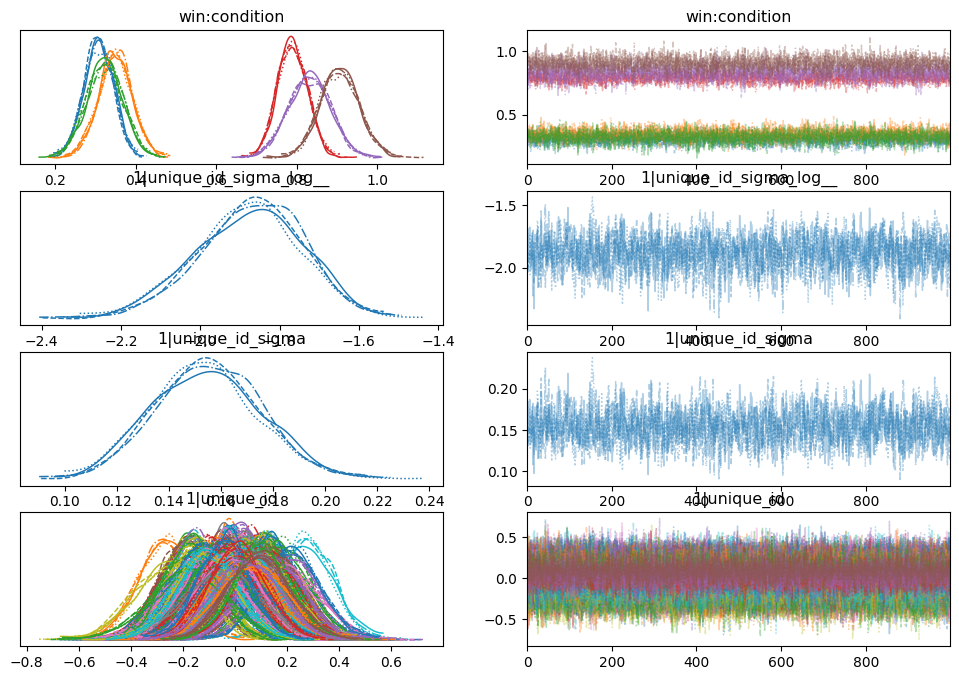

In [21]:
# Use ArviZ to plot the results
az.plot_trace(nutpie_idata)

In [ ]:
model.predict(nutpie_idata)

In [42]:
nutpie_idata.posterior_predictive

<xarray.Dataset> Size: 15MB
Dimensions:                (chain: 4, draw: 1000, __obs__: 477)
Coordinates:
  * chain                  (chain) int64 32B 0 1 2 3
  * draw                   (draw) int64 8kB 0 1 2 3 4 5 ... 995 996 997 998 999
  * __obs__                (__obs__) int64 4kB 0 1 2 3 4 ... 472 473 474 475 476
Data variables:
    p(n_correct, n_turns)  (chain, draw, __obs__) int64 15MB 44 33 41 ... 22 9
Attributes:
    modeling_interface:          bambi
    modeling_interface_version:  0.17.2

<Axes: xlabel='p(n_correct, n_turns)'>

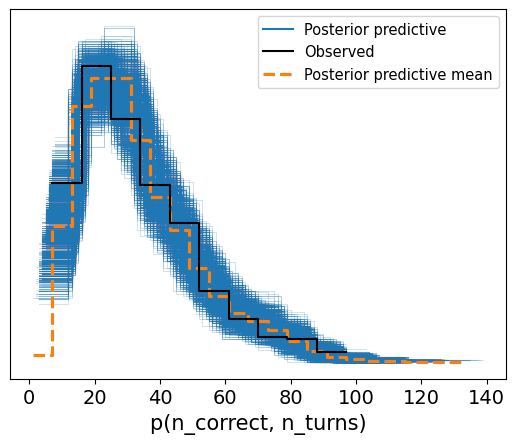

In [31]:
az.plot_ppc(nutpie_idata)

In [64]:
model

       Formula: p(n_correct, n_turns) ~ 0 + win:condition + (1|unique_id)
        Family: binomial
          Link: p = logit
  Observations: 477
        Priors: 
    target = p
        Common-level effects
            win:condition ~ Normal(mu: [0. 0. 0. 0. 0. 0.], sigma: [1. 1. 1. 1. 1. 1.])
        
        Group-level effects
            1|unique_id ~ Normal(mu: 0.0, sigma: HalfNormal(sigma: 2.5371))

In [ ]:
"""bf(Median_t1_same ~ 0 + ASD + ASD:Visit + ASD:Visit:Median_t_same + ASD:Visit:Median_t_other + (1 + Visit:Median_t_same + Visit:Median_t_other |gr(Participant, by=ASD)),
              sigma ~ 0 + ASD + ASD:Visit + ASD:Visit:Median_t_same + ASD:Visit:Median_t_other + ( 1 |gr(Participant, by=ASD)),
              family = lognormal())
"""

In [ ]:
preds = model.predict(nutpie_idata, kind="response_params", inplace=False)
posterior_preds = np.array(preds["posterior_predictive"]["p(n_correct, n_turns)"])
new_arr = posterior_preds.reshape(-1, posterior_preds.shape[-1])
new_arr = np.transpose(new_arr)
subs_list = []
for game_id_idx, game_id in enumerate(list(cut_df["game_id"])):
    temp_dict = {"game_id":game_id,
     "preds":new_arr[game_id_idx]}
    subs_list.append(temp_dict)

pred_df = cut_df.merge(pd.DataFrame(subs_list), on="game_id")

In [205]:
pred_df

,game_id,unique_id,condition,win,n_turns,n_correct,preds
0,1_10_2_2,1_10_2,1_I,Lose,68,32,"[44, 41, 40, 42, 32, 42, 39, 42, 37, 38, 34, 3..."
1,1_10_2_3,1_10_2,1_I,Lose,74,45,"[33, 39, 36, 45, 35, 47, 47, 37, 38, 43, 48, 4..."
2,1_10_2_4,1_10_2,1_I,Lose,69,50,"[41, 37, 39, 42, 44, 50, 35, 38, 38, 37, 46, 3..."
3,1_11_1_2,1_11_1,1_I,Win,97,61,"[76, 58, 64, 69, 69, 64, 74, 66, 63, 70, 59, 6..."
4,1_11_1_3,1_11_1,1_I,Win,55,38,"[39, 34, 38, 40, 40, 42, 34, 33, 29, 30, 34, 4..."
...,...,...,...,...,...,...,...
472,3_9_1_2,3_9_1,3_D,Win,21,16,"[15, 14, 16, 16, 13, 14, 16, 15, 15, 13, 16, 1..."
473,3_9_1_3,3_9_1,3_D,Lose,53,30,"[35, 32, 31, 37, 30, 33, 30, 39, 41, 33, 31, 3..."
474,3_9_1_4,3_9_1,3_D,Win,48,36,"[38, 31, 39, 27, 37, 36, 34, 31, 35, 29, 34, 3..."
475,3_9_1_5,3_9_1,3_D,Win,30,24,"[25, 21, 21, 18, 21, 23, 22, 24, 23, 20, 22, 2..."


In [206]:
from scipy.stats import wasserstein_distance